# Guided Clausius Beta Branch Recompute

This notebook rebuilds the Clausius beta-equilibrium branch scan from guided-style requests, recomputes the postprocessed sound-speed curve with the same local polynomial settings (`window=29`, `degree=3`), and plots `f_Q`, `v_s^2`, `\epsilon/\rho_B-m_N`, and `P` inline.

It also computes fixed-`y` finite-temperature critical points for both asymmetric branches and plots `T_c(y)`, `n_c(y)`, `T_c` vs `n_c`, and `K_0` vs `n_c`.

The plot lower x-limit is set to `0.05` by default so the near-zero artifact is not shown.

In [1]:
from pathlib import Path
import csv
import json
import math
import sys
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

candidate_roots = []
seen = set()
for base in [Path.cwd(), *Path.cwd().parents]:
    for candidate in (base, base / 'QMM'):
        resolved = candidate.resolve()
        marker = str(resolved)
        if marker not in seen:
            seen.add(marker)
            candidate_roots.append(resolved)

ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'qmm').exists() and (candidate / 'examples').exists():
        ROOT = candidate
        break
if ROOT is None:
    raise RuntimeError('Could not find the QMM project root from this notebook.')

SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qmm.asymmetry import AsymmetricFitResult
from qmm.constants import DEFAULT_PHYSICAL_CONSTANTS
from qmm.fixed_y_quantum import compute_fixed_y_family, fixed_y_quantum_settings
from qmm.qmm_json_helper import (
    build_configs,
    choose_python,
    default_request,
    python_details,
    run_configs,
    save_configs,
    summarize_run,
)

PHYSICAL = DEFAULT_PHYSICAL_CONSTANTS
PYTHON_BIN = choose_python(ROOT)
PYTHON_INFO = python_details(ROOT, PYTHON_BIN)
NOTEBOOK_OUTPUT_DIR = ROOT / 'results' / 'generated' / 'guided_clausius_beta_branch_recompute'
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'QMM root: {ROOT}')
print(f'Runner Python: {PYTHON_BIN}')
print(f'Runner version: {PYTHON_INFO["version"]}')
print(f'Matplotlib available for runner: {PYTHON_INFO["has_matplotlib"]}')
print(f'Notebook output directory: {NOTEBOOK_OUTPUT_DIR.relative_to(ROOT)}')


QMM root: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM
Runner Python: /opt/anaconda3/envs/tovsolver/bin/python
Runner version: [3, 11, 15]
Matplotlib available for runner: True
Notebook output directory: results/generated/guided_clausius_beta_branch_recompute


In [2]:
BASE_PREFIX = 'guided_clausius_beta_branch_recompute'
K0_VALUES = [250,255, 260,265, 270,275, 280,285, 290,295, 300,305,310, 315]
SELECTED_K0_VALUES = [250, 280, 315]
FORCE_RERUN = False
RERUN_IF_SOURCE_NEWER = True

# This matches the historical Clausius asymmetric scan structure.
PRESET = 'asymmetric_beta_neutron_star'
WRITE_RUNNER_PLOTS = False

# Postprocessing controls for the sound-speed reconstruction.
WINDOW = 29
DEGREE = 3
X_MIN = 0.05
X_MAX = 5.0

# Fixed-y finite-temperature critical-point scan.
# FIXED_Y_VALUES = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
FIXED_Y_VALUES = np.linspace(0.0, 0.5, 10)


SOURCE_DEPENDENCIES = [
    ROOT / 'src' / 'qmm' / 'asymmetry.py',
    ROOT / 'src' / 'qmm' / 'quarkyonic.py',
    ROOT / 'src' / 'qmm' / 'sound_speed.py',
    ROOT / 'src' / 'qmm' / 'qmm_json_helper.py',
]

def guided_request_for_k0(target_k0):
    request = default_request()
    request.update(
        {
            'run_name': f'{BASE_PREFIX}_k0_{int(round(target_k0))}',
            'output_subdir': f'{BASE_PREFIX}/K0_{int(round(target_k0))}',
            'mean_field': 'clausius',
            'excluded_volume': 'vdw',
            'model_name': 'clausius',
            'preset': PRESET,
            'parameter_mode': 'search',
            'parameter_value': None,
            'target_k0': float(target_k0),
            'quick_mode': False,
            'momentum_mode': 'quarkyonic',
            'lambda_momentum_mev': 200.0,
            'branch_mode': 'both',
            'beta_equilibrium': True,
            'proton_fraction_values': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
            'write_json': True,
            'write_csv': True,
            'write_plots': WRITE_RUNNER_PLOTS,
            'plot_formats': ['png'] if WRITE_RUNNER_PLOTS else [],
        }
    )
    return request

requests = [guided_request_for_k0(target_k0) for target_k0 in K0_VALUES]
configs = []
for request in requests:
    configs.extend(build_configs(ROOT, request, PYTHON_BIN))

for config in configs:
    config['output']['write_plots'] = WRITE_RUNNER_PLOTS
    config['output']['plot_formats'] = ['png'] if WRITE_RUNNER_PLOTS else []
    config['model']['parameter_search']['scan_steps'] = 121
    config['model']['parameter_search']['tol'] = 1.0e-8
    config['hadronic_eos']['n_min_ratio'] = 0.2
    config['hadronic_eos']['n_max_ratio'] = 5.0
    config['hadronic_eos']['n_points'] = 160
    config['hadronic_eos']['smoothing_window'] = 9
    config['hadronic_eos']['smoothing_degree'] = 3
    config['hadronic_eos']['derivative_floor'] = 1.0e-10
    config['quarkyonic']['n_min_ratio'] = 1.0e-6
    config['quarkyonic']['n_max_ratio'] = 5.0
    config['quarkyonic']['n_points'] = 60
    config['quarkyonic']['fq_scan_points'] = 61
    config['quarkyonic']['shell_integral_points'] = 100
    config['quarkyonic']['quark_integral_points'] = 100
    config['quarkyonic']['smoothing_window'] = 9
    config['quarkyonic']['smoothing_degree'] = 3
    config['quarkyonic']['lambda_momentum_mev'] = 200.0
    config['asymmetric']['beta_equilibrium'] = True
    config['asymmetric']['proton_fraction_values'] = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    if config['workflows'].get('neutron_star'):
        config['neutron_star']['sequence_points'] = 12

print(f'Generated {len(configs)} config(s):')
for config in configs:
    print(
        f"- {config['run_name']} | branch={config['asymmetric']['branch_mode']} "
        f"| target_k0={config['model']['parameter_search']['target_k0']}"
    )

config_paths = save_configs(ROOT, configs)
for path in config_paths:
    print(f'Saved config: {path.relative_to(ROOT)}')

print(f'Plot x-range: ({X_MIN}, {X_MAX})')
print(f'Postprocess window={WINDOW}, degree={DEGREE}')
print(f'Fixed-y critical-point grid: {FIXED_Y_VALUES}')


Generated 28 config(s):
- guided_clausius_beta_branch_recompute_k0_250_target_l | branch=target_l | target_k0=250.0
- guided_clausius_beta_branch_recompute_k0_250_equal_b | branch=equal_b | target_k0=250.0
- guided_clausius_beta_branch_recompute_k0_255_target_l | branch=target_l | target_k0=255.0
- guided_clausius_beta_branch_recompute_k0_255_equal_b | branch=equal_b | target_k0=255.0
- guided_clausius_beta_branch_recompute_k0_260_target_l | branch=target_l | target_k0=260.0
- guided_clausius_beta_branch_recompute_k0_260_equal_b | branch=equal_b | target_k0=260.0
- guided_clausius_beta_branch_recompute_k0_265_target_l | branch=target_l | target_k0=265.0
- guided_clausius_beta_branch_recompute_k0_265_equal_b | branch=equal_b | target_k0=265.0
- guided_clausius_beta_branch_recompute_k0_270_target_l | branch=target_l | target_k0=270.0
- guided_clausius_beta_branch_recompute_k0_270_equal_b | branch=equal_b | target_k0=270.0
- guided_clausius_beta_branch_recompute_k0_275_target_l | branch=t

In [3]:
def summary_path_for_config(config):
    return ROOT / config['output']['directory'] / f"{config['run_name']}_summary.json"

def summaries_stale(paths):
    if not RERUN_IF_SOURCE_NEWER:
        return False
    existing = [path for path in paths if path.exists()]
    sources = [path for path in SOURCE_DEPENDENCIES if path.exists()]
    if not existing or not sources:
        return False
    newest_source = max(path.stat().st_mtime for path in sources)
    oldest_summary = min(path.stat().st_mtime for path in existing)
    return newest_source > oldest_summary

summary_paths = [summary_path_for_config(config) for config in configs]
need_run = FORCE_RERUN or not all(path.exists() for path in summary_paths) or summaries_stale(summary_paths)

if need_run:
    run_results = run_configs(ROOT, config_paths, PYTHON_BIN)
else:
    run_results = []
    for path in summary_paths:
        run_results.append(
            {
                'command': None,
                'stdout': '',
                'stderr': '',
                'summary': json.loads(path.read_text(encoding='utf-8')),
                'summary_path': path,
            }
        )

for result in run_results:
    print('Command used:' if result['command'] else 'Loaded existing summary:')
    print(result['command'] or result['summary_path'].relative_to(ROOT))
    print()
    print(summarize_run(result['summary']))
    print()


Command used:
/opt/anaconda3/envs/tovsolver/bin/python -m qmm examples/generated/guided_clausius_beta_branch_recompute_k0_250_target_l.json

run_name: guided_clausius_beta_branch_recompute_k0_250_target_l
model: clausius
summary_json: results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_branch_recompute_k0_250_target_l_summary.json
asymmetric_beta_csv: results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_branch_recompute_k0_250_target_l_asymmetric_beta.csv
asymmetric_fit_csv: results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_branch_recompute_k0_250_target_l_asymmetric_fit.csv
asymmetric_y_0.000_csv: results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_branch_recompute_k0_250_target_l_asymmetric_y_0.000.csv
asymmetric_y_0.100_csv: results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_bran

In [4]:
def resolve_output_path(path_text):
    path = Path(path_text)
    return path if path.is_absolute() else ROOT / path

def load_beta_curve(path):
    with path.open('r', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    curve = {}
    fields = ['n_b', 'n_over_n0', 'y', 'quark_fraction', 'energy_density', 'pressure', 'vs2', 'mu_e', 'eps_mu']
    for key in fields:
        curve[key] = np.array(
            [
                float(row[key]) if row.get(key, '') not in {'', 'nan', 'None'} else np.nan
                for row in rows
            ],
            dtype=float,
        )
    order = np.argsort(curve['n_over_n0'])
    for key in curve:
        curve[key] = curve[key][order]
    return curve

def local_polynomial_regression(x_values, y_values, window_size, degree):
    if window_size % 2 == 0:
        window_size += 1
    half = window_size // 2
    count = len(x_values)
    smoothed = np.empty(count, dtype=float)
    first = np.empty(count, dtype=float)
    second = np.empty(count, dtype=float)
    for index in range(count):
        left = max(0, index - half)
        right = min(count, index + half + 1)
        if right - left < degree + 1:
            if left == 0:
                right = min(count, degree + 1)
            else:
                left = max(0, count - degree - 1)
        x_center = x_values[index]
        x_local = x_values[left:right] - x_center
        y_local = y_values[left:right]
        design = np.vstack([x_local ** power for power in range(degree + 1)]).T
        coeffs, *_ = np.linalg.lstsq(design, y_local, rcond=None)
        smoothed[index] = coeffs[0]
        first[index] = coeffs[1] if degree >= 1 else 0.0
        second[index] = 2.0 * coeffs[2] if degree >= 2 else 0.0
    return smoothed, first, second

def reconstruct_vs2(densities, energy_density, window_size, degree, derivative_floor=1.0e-12):
    eps_smooth, mu_b, d2eps = local_polynomial_regression(densities, energy_density, window_size, degree)
    pressure = densities * mu_b - eps_smooth
    dP_dn = densities * d2eps
    vs2 = np.full_like(mu_b, np.nan)
    valid = (
        np.isfinite(mu_b)
        & np.isfinite(d2eps)
        & np.isfinite(dP_dn)
        & (np.abs(mu_b) >= derivative_floor)
    )
    vs2[valid] = dP_dn[valid] / mu_b[valid]
    return pressure, mu_b, vs2

def energy_per_baryon_minus_m(energy_density, density):
    return (energy_density / density - PHYSICAL.m_nucleon) / 1000.0

curve_results = {}
fit_rows = []
for result in run_results:
    summary = result['summary']
    fit = summary['asymmetric_fit']
    k0 = int(round(float(fit['K0'])))
    branch_mode = fit['branch_mode']
    beta_csv = resolve_output_path(summary['outputs']['asymmetric_beta_csv'])
    curve = load_beta_curve(beta_csv)
    pressure_reconstructed, mu_b_reconstructed, vs2_reconstructed = reconstruct_vs2(
        curve['n_b'],
        curve['energy_density'],
        WINDOW,
        DEGREE,
    )
    curve['pressure_reconstructed'] = pressure_reconstructed
    curve['mu_b_reconstructed'] = mu_b_reconstructed
    curve['vs2_reconstructed'] = vs2_reconstructed
    curve_results[(k0, branch_mode)] = {
        'summary': summary,
        'curve': curve,
        'beta_csv': beta_csv,
    }
    fit_rows.append(
        {
            'K0_MeV': k0,
            'branch_mode': branch_mode,
            'a_pn_over_a_n': round(float(fit['ratio_a_pn_over_a_n']), 6),
            'b_pn_over_b_n': round(float(fit['ratio_b_pn_over_b_n']), 6),
            'J': round(float(fit['J']), 6),
            'L': round(float(fit['L']), 6),
            'beta_csv': str(beta_csv.relative_to(ROOT)),
        }
    )

for key in sorted(curve_results):
    print(f'{key}: {curve_results[key]["beta_csv"].relative_to(ROOT)}')

try:
    import pandas as pd
    display(pd.DataFrame(fit_rows).sort_values(['K0_MeV', 'branch_mode']).reset_index(drop=True))
except Exception:
    from pprint import pprint
    pprint(fit_rows)


(250, 'equal_b'): results/generated/guided_clausius_beta_branch_recompute/K0_250_equal_b/guided_clausius_beta_branch_recompute_k0_250_equal_b_asymmetric_beta.csv
(250, 'target_l'): results/generated/guided_clausius_beta_branch_recompute/K0_250_target_l/guided_clausius_beta_branch_recompute_k0_250_target_l_asymmetric_beta.csv
(255, 'equal_b'): results/generated/guided_clausius_beta_branch_recompute/K0_255_equal_b/guided_clausius_beta_branch_recompute_k0_255_equal_b_asymmetric_beta.csv
(255, 'target_l'): results/generated/guided_clausius_beta_branch_recompute/K0_255_target_l/guided_clausius_beta_branch_recompute_k0_255_target_l_asymmetric_beta.csv
(260, 'equal_b'): results/generated/guided_clausius_beta_branch_recompute/K0_260_equal_b/guided_clausius_beta_branch_recompute_k0_260_equal_b_asymmetric_beta.csv
(260, 'target_l'): results/generated/guided_clausius_beta_branch_recompute/K0_260_target_l/guided_clausius_beta_branch_recompute_k0_260_target_l_asymmetric_beta.csv
(265, 'equal_b'): r

,K0_MeV,branch_mode,a_pn_over_a_n,b_pn_over_b_n,J,L,beta_csv
0,250,equal_b,2.314329,1.000000,32.5,70.058236,results/generated/guided_clausius_beta_branch_...
1,250,target_l,2.641500,1.623344,32.5,58.900000,results/generated/guided_clausius_beta_branch_...
2,255,equal_b,2.296590,1.000000,32.5,70.765359,results/generated/guided_clausius_beta_branch_...
3,255,target_l,2.639792,1.645184,32.5,58.900000,results/generated/guided_clausius_beta_branch_...
4,260,equal_b,2.279404,1.000000,32.5,71.465148,results/generated/guided_clausius_beta_branch_...
5,260,target_l,2.638023,1.665397,32.5,58.900000,results/generated/guided_clausius_beta_branch_...
6,265,equal_b,2.262743,1.000000,32.5,72.157813,results/generated/guided_clausius_beta_branch_...
7,265,target_l,2.636198,1.684110,32.5,58.900000,results/generated/guided_clausius_beta_branch_...
8,270,equal_b,2.246582,1.000000,32.5,72.843552,results/generated/guided_clausius_beta_branch_...
9,270,target_l,2.634319,1.701439,32.5,58.900000,results/generated/guided_clausius_beta_branch_...


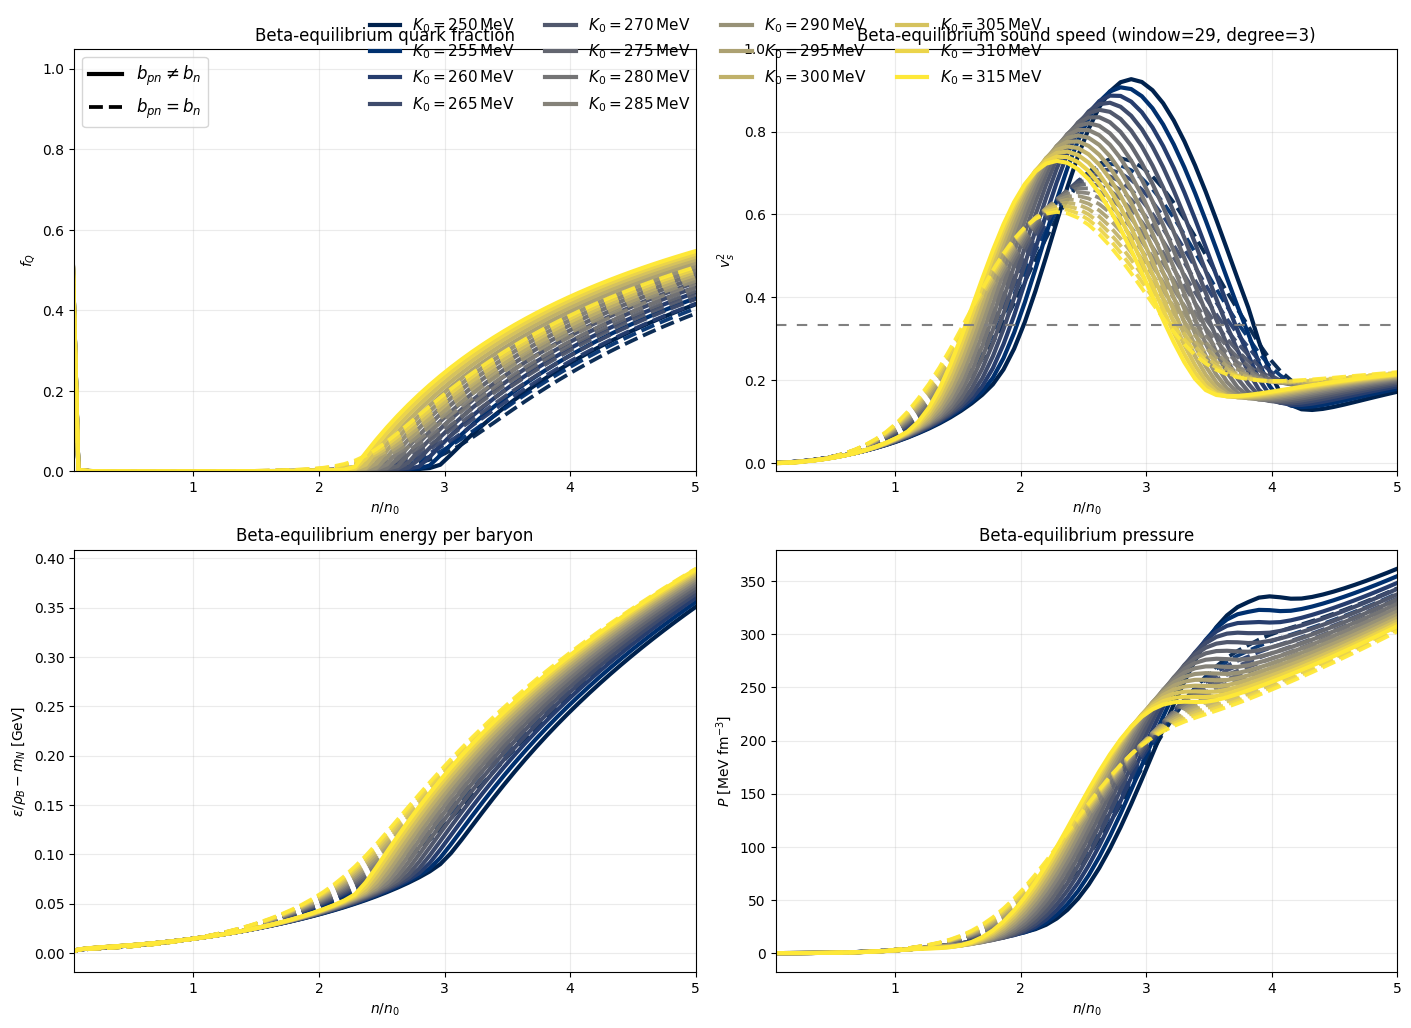

,K0_MeV,branch_mode,n_over_n0_at_peak,quark_fraction_at_peak,vs2_peak
0,250,equal_b,2.796611,0.021413,0.735785
1,250,target_l,2.881356,0.008475,0.926425
2,255,equal_b,2.711865,0.019702,0.722044
3,255,target_l,2.796611,0.007694,0.906722
4,260,equal_b,2.711865,0.024414,0.707904
5,260,target_l,2.711865,0.006859,0.886759
6,265,equal_b,2.627119,0.021745,0.696667
7,265,target_l,2.711865,0.009502,0.869554
8,270,equal_b,2.542373,0.019050,0.684307
9,270,target_l,2.627119,0.007634,0.852510


Saved figure: results/generated/guided_clausius_beta_branch_recompute/guided_clausius_branch_comparison_same_k0_colors.png
Saved peak summary: results/generated/guided_clausius_beta_branch_recompute/beta_sound_speed_peak_summary.csv


In [5]:
peak_rows = []
for (k0, branch_mode), item in sorted(curve_results.items()):
    curve = item['curve']
    values = curve['vs2_reconstructed']
    idx = int(np.nanargmax(values))
    peak_rows.append(
        {
            'K0_MeV': k0,
            'branch_mode': branch_mode,
            'n_over_n0_at_peak': round(float(curve['n_over_n0'][idx]), 6),
            'quark_fraction_at_peak': round(float(curve['quark_fraction'][idx]), 6),
            'vs2_peak': round(float(values[idx]), 6),
        }
    )

peak_summary_csv = NOTEBOOK_OUTPUT_DIR / 'beta_sound_speed_peak_summary.csv'
with peak_summary_csv.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(peak_rows[0].keys()))
    writer.writeheader()
    writer.writerows(peak_rows)

all_vs2 = []
for item in curve_results.values():
    values = item['curve']['vs2_reconstructed']
    all_vs2.extend([float(value) for value in values if np.isfinite(value)])
vs_ylim = max(1.0, 1.05 * max(all_vs2))

paired_cmap = plt.get_cmap('cividis')
denominator = max(len(K0_VALUES) - 1, 1)
paired_colors = {
    int(k0): paired_cmap(index / denominator)
    for index, k0 in enumerate(K0_VALUES)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
ax_fq, ax_vs, ax_e, ax_p = axes.flat

for k0 in K0_VALUES:
    color = paired_colors[int(k0)]
    for branch_mode, linestyle, alpha in [('target_l', '-', 1.0), ('equal_b', '--', 0.95)]:
        curve = curve_results[(int(k0), branch_mode)]['curve']
        x = curve['n_over_n0']
        ax_fq.plot(x, curve['quark_fraction'], color=color, lw=3.0 if branch_mode == 'target_l' else 2.7, ls=linestyle, alpha=alpha)
        ax_vs.plot(x, curve['vs2_reconstructed'], color=color, lw=3.0 if branch_mode == 'target_l' else 2.7, ls=linestyle, alpha=alpha)
        ax_e.plot(x, energy_per_baryon_minus_m(curve['energy_density'], curve['n_b']), color=color, lw=3.0 if branch_mode == 'target_l' else 2.7, ls=linestyle, alpha=alpha)
        ax_p.plot(x, curve['pressure_reconstructed'], color=color, lw=3.0 if branch_mode == 'target_l' else 2.7, ls=linestyle, alpha=alpha)

ax_fq.set_xlabel(r'$n/n_0$')
ax_fq.set_ylabel(r'$f_Q$')
ax_fq.set_title('Beta-equilibrium quark fraction')
ax_fq.set_ylim(0.0, 1.05)

branch_handles = [
    Line2D([0], [0], color='black', lw=3.0, ls='-', label='$b_{pn} \\neq b_n$'),
    Line2D([0], [0], color='black', lw=2.7, ls='--', label=r'$b_{pn} = b_n$'),
]
ax_fq.legend(handles=branch_handles, loc='upper left', frameon=True, fontsize=12)

ax_vs.set_xlabel(r'$n/n_0$')
ax_vs.set_ylabel(r'$v_s^2$')
ax_vs.set_title(f'Beta-equilibrium sound speed (window={WINDOW}, degree={DEGREE})')
ax_vs.axhline(1.0 / 3.0, color='gray', lw=1.5, ls=(0, (5, 5)))
ax_vs.set_ylim(-0.02, vs_ylim)

ax_e.set_xlabel(r'$n/n_0$')
ax_e.set_ylabel(r'$\epsilon/\rho_B - m_N$ [GeV]')
ax_e.set_title('Beta-equilibrium energy per baryon')

ax_p.set_xlabel(r'$n/n_0$')
ax_p.set_ylabel(r'$P$ [MeV fm$^{-3}$]')
ax_p.set_title('Beta-equilibrium pressure')

k0_handles = [
    Line2D([0], [0], color=paired_colors[int(k0)], lw=3.0, label=f'$K_0={int(k0)}\\,\\mathrm{{MeV}}$')
    for k0 in K0_VALUES
]
fig.legend(handles=k0_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False, fontsize=11)

for axis in axes.flat:
    axis.grid(True, alpha=0.25)
    axis.set_xlim(X_MIN, X_MAX)

comparison_png = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_branch_comparison_same_k0_colors.png'
comparison_pdf = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_branch_comparison_same_k0_colors.pdf'
fig.savefig(comparison_png, dpi=220, bbox_inches='tight')
fig.savefig(comparison_pdf, bbox_inches='tight')
plt.show()

try:
    import pandas as pd
    display(pd.DataFrame(peak_rows).sort_values(['K0_MeV', 'branch_mode']).reset_index(drop=True))
except Exception:
    from pprint import pprint
    pprint(peak_rows)

print(f'Saved figure: {comparison_png.relative_to(ROOT)}')
print(f'Saved peak summary: {peak_summary_csv.relative_to(ROOT)}')


In [6]:
fixed_y_settings = fixed_y_quantum_settings()
fixed_y_results = []
fixed_y_status_rows = []

fits_by_branch = {'target_l': [], 'equal_b': []}
for result in run_results:
    fit = AsymmetricFitResult(**result['summary']['asymmetric_fit'])
    fits_by_branch.setdefault(fit.branch_mode, []).append(fit)

for branch_mode in fits_by_branch:
    fits_by_branch[branch_mode] = sorted(
        fits_by_branch[branch_mode],
        key=lambda fit: float(fit.target_k0) if fit.target_k0 is not None else math.nan,
    )

for branch_mode, fits in fits_by_branch.items():
    if not fits:
        continue
    print(f'Computing fixed-y critical family for {branch_mode} over {len(fits)} K0 points...')
    branch_results, branch_statuses = compute_fixed_y_family(
        fits,
        FIXED_Y_VALUES,
        physical=PHYSICAL,
        settings=fixed_y_settings,
    )
    for item in branch_results:
        row = asdict(item)
        row['branch_mode'] = branch_mode
        fixed_y_results.append(row)
    for item in branch_statuses:
        row = asdict(item)
        row['branch_mode'] = branch_mode
        fixed_y_status_rows.append(row)

fixed_y_results.sort(key=lambda row: (row['branch_mode'], float(row['y']), float(row['target_k0'])))
fixed_y_status_rows.sort(key=lambda row: (row['branch_mode'], float(row['y']), float(row['target_k0'])))

fixed_y_results_csv = NOTEBOOK_OUTPUT_DIR / 'fixed_y_quantum_summary.csv'
fixed_y_status_csv = NOTEBOOK_OUTPUT_DIR / 'fixed_y_quantum_branch_status.csv'
with fixed_y_results_csv.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(fixed_y_results[0].keys()))
    writer.writeheader()
    writer.writerows(fixed_y_results)
with fixed_y_status_csv.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.DictWriter(handle, fieldnames=list(fixed_y_status_rows[0].keys()))
    writer.writeheader()
    writer.writerows(fixed_y_status_rows)

status_failures = [row for row in fixed_y_status_rows if row['status'] != 'converged']
print(f'Converged fixed-y critical points: {len(fixed_y_results)}')
print(f'Non-converged fixed-y branch states: {len(status_failures)}')

try:
    import pandas as pd
    display(pd.DataFrame(fixed_y_results))
    if status_failures:
        display(pd.DataFrame(status_failures))
except Exception:
    from pprint import pprint
    pprint(fixed_y_results[:6])
    if status_failures:
        pprint(status_failures[:6])

print(f'Saved: {fixed_y_results_csv.relative_to(ROOT)}')
print(f'Saved: {fixed_y_status_csv.relative_to(ROOT)}')


Computing fixed-y critical family for target_l over 14 K0 points...
Computing fixed-y critical family for equal_b over 14 K0 points...
Converged fixed-y critical points: 223
Non-converged fixed-y branch states: 57


,model,parameter_name,parameter_value,target_k0,y,Tc,nc,Pc,dPdn,d2Pdn2,...,iterations,mu_p_star,mu_n_star,a_avg,b_avg,a_n,a_pn,b_n,b_pn,branch_mode
0,clausius,c,4.735853,250.0,0.111111,6.394464,0.031419,0.062741,2.006992e-07,0.000066,...,12,934.294392,954.597064,472.327509,1.727371,285.021459,659.633558,1.727371,1.727371,equal_b
1,clausius,c,4.624418,255.0,0.111111,6.438532,0.031721,0.063896,1.551123e-07,0.000046,...,12,934.275990,954.724246,469.132228,1.764613,284.616705,653.647750,1.764613,1.764613,equal_b
2,clausius,c,4.516312,260.0,0.111111,6.482032,0.032018,0.065048,3.460983e-07,0.000075,...,11,934.257852,954.849831,466.026020,1.800838,284.213883,647.838157,1.800838,1.800838,equal_b
3,clausius,c,4.411374,265.0,0.111111,6.524984,0.032312,0.066198,1.742130e-06,0.000008,...,9,934.239960,954.973862,463.004732,1.836091,283.813148,642.196316,1.836091,1.836091,equal_b
4,clausius,c,4.309453,270.0,0.111111,6.567398,0.032602,0.067346,-5.017597e-08,-0.000059,...,11,934.222324,955.096394,460.064471,1.870418,283.414635,636.714307,1.870418,1.870418,equal_b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,clausius,c,3.840478,295.0,0.500000,16.631298,0.053088,0.271713,-3.779026e-06,0.000051,...,10,941.216383,941.216383,446.458711,2.029487,246.374246,646.543177,1.464979,2.593995,target_l
219,clausius,c,3.753994,300.0,0.500000,16.679880,0.053413,0.274930,-3.793855e-06,0.000057,...,10,941.315736,941.315736,443.935490,2.059026,245.126408,642.744572,1.480464,2.637588,target_l
220,clausius,c,3.669708,305.0,0.500000,16.727853,0.053735,0.278130,-3.808417e-06,0.000064,...,10,941.413861,941.413861,441.471994,2.087878,243.912420,639.031568,1.495773,2.679982,target_l
221,clausius,c,3.587529,310.0,0.500000,16.775235,0.054051,0.281315,-3.822759e-06,0.000070,...,10,941.510793,941.510793,439.065849,2.116069,242.730857,635.400841,1.510911,2.721226,target_l


,target_k0,y,status,branch_mode
0,250.0,0.000000,no_solution_in_window,equal_b
1,255.0,0.000000,no_solution_in_window,equal_b
2,260.0,0.000000,no_solution_in_window,equal_b
3,265.0,0.000000,no_solution_in_window,equal_b
4,270.0,0.000000,no_solution_in_window,equal_b
5,275.0,0.000000,no_solution_in_window,equal_b
6,280.0,0.000000,no_solution_in_window,equal_b
7,285.0,0.000000,no_solution_in_window,equal_b
8,290.0,0.000000,no_solution_in_window,equal_b
9,295.0,0.000000,no_solution_in_window,equal_b


Saved: results/generated/guided_clausius_beta_branch_recompute/fixed_y_quantum_summary.csv
Saved: results/generated/guided_clausius_beta_branch_recompute/fixed_y_quantum_branch_status.csv


In [7]:
if not fixed_y_results:
    raise ValueError('No fixed-y critical points were computed.')

branch_styles = {
    'target_l': {'linestyle': '-', 'marker': 'o', 'label': '$b_{pn} \\neq b_n$'},
    'equal_b': {'linestyle': '--', 'marker': 's', 'label': r'$b_{pn} = b_n$'},
}

k0_cmap = plt.get_cmap('cividis')
k0_denominator = max(len(K0_VALUES) - 1, 1)
k0_colors = {
    int(k0): k0_cmap(index / k0_denominator)
    for index, k0 in enumerate(K0_VALUES)
}

y_cmap = plt.get_cmap('viridis')
y_denominator = max(len(FIXED_Y_VALUES) - 1, 1)
y_colors = {
    round(float(y_value), 3): y_cmap(index / y_denominator)
    for index, y_value in enumerate(FIXED_Y_VALUES)
}

fig_y, axes_y = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)
for k0 in K0_VALUES:
    color = k0_colors[int(k0)]
    for branch_mode in ['target_l', 'equal_b']:
        rows = [
            row for row in fixed_y_results
            if row['branch_mode'] == branch_mode and int(round(float(row['target_k0']))) == int(k0)
        ]
        rows = sorted(rows, key=lambda row: float(row['y']))
        if not rows:
            continue
        y_values = [float(row['y']) for row in rows]
        tc_values = [float(row['Tc']) for row in rows]
        nc_values = [float(row['nc']) for row in rows]
        style = branch_styles[branch_mode]
        axes_y[0].plot(y_values, tc_values, color=color, ls=style['linestyle'], marker=style['marker'], lw=2.0, ms=5.0)
        axes_y[1].plot(y_values, nc_values, color=color, ls=style['linestyle'], marker=style['marker'], lw=2.0, ms=5.0)

axes_y[0].set_title(r'$T_c$ vs fixed $y$')
axes_y[0].set_xlabel(r'$y$')
axes_y[0].set_ylabel(r'$T_c$ [MeV]')
axes_y[1].set_title(r'$n_c$ vs fixed $y$')
axes_y[1].set_xlabel(r'$y$')
axes_y[1].set_ylabel(r'$n_c$ [fm$^{-3}$]')

for axis in axes_y:
    axis.grid(True, alpha=0.25)

k0_handles = [
    Line2D([0], [0], color=k0_colors[int(k0)], lw=2.5, label=f'$K_0={int(k0)}\\,\\mathrm{{MeV}}$')
    for k0 in K0_VALUES
]
branch_handles = [
    Line2D([0], [0], color='black', lw=2.2, ls=branch_styles[branch_mode]['linestyle'], marker=branch_styles[branch_mode]['marker'], label=branch_styles[branch_mode]['label'])
    for branch_mode in ['target_l', 'equal_b']
]
axes_y[0].legend(handles=k0_handles, loc='best', fontsize=8, title=r'$K_0$')
axes_y[1].legend(handles=branch_handles, loc='best', fontsize=10, title='branch')

fixed_y_by_y_png = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_fixed_y_vs_y.png'
fixed_y_by_y_pdf = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_fixed_y_vs_y.pdf'
fig_y.savefig(fixed_y_by_y_png, dpi=220, bbox_inches='tight')
fig_y.savefig(fixed_y_by_y_pdf, bbox_inches='tight')
plt.show()

fig_cross, axes_cross = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)
for y_value in FIXED_Y_VALUES:
    y_key = round(float(y_value), 3)
    color = y_colors[y_key]
    for branch_mode in ['target_l', 'equal_b']:
        rows = [
            row for row in fixed_y_results
            if row['branch_mode'] == branch_mode and round(float(row['y']), 3) == y_key
        ]
        rows = sorted(rows, key=lambda row: float(row['target_k0']))
        if not rows:
            continue
        nc_values = [float(row['nc']) for row in rows]
        tc_values = [float(row['Tc']) for row in rows]
        k0_values = [float(row['target_k0']) for row in rows]
        style = branch_styles[branch_mode]
        axes_cross[0].plot(nc_values, tc_values, color=color, ls=style['linestyle'], marker=style['marker'], lw=2.0, ms=5.0)
        axes_cross[1].plot(k0_values, nc_values, color=color, ls=style['linestyle'], marker=style['marker'], lw=2.0, ms=5.0)

axes_cross[0].set_title(r'$T_c$ vs $n_c$ by fixed $y$')
axes_cross[0].set_xlabel(r'$n_c$ [fm$^{-3}$]')
axes_cross[0].set_ylabel(r'$T_c$ [MeV]')
axes_cross[1].set_title(r'$K_0$ vs $n_c$ by fixed $y$')
axes_cross[1].set_xlabel(r'$K_0$ [MeV]')
axes_cross[1].set_ylabel(r'$n_c$ [fm$^{-3}$]')

for axis in axes_cross:
    axis.grid(True, alpha=0.25)

y_handles = [
    Line2D([0], [0], color=y_colors[round(float(y_value), 3)], lw=2.5, label=rf'$y={float(y_value):.2f}$')
    for y_value in FIXED_Y_VALUES
]
axes_cross[0].legend(handles=y_handles, loc='best', fontsize=9, title='fixed y')
axes_cross[1].legend(handles=branch_handles, loc='best', fontsize=10, title='branch')

fixed_y_cross_png = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_fixed_y_tc_nc_branches.png'
fixed_y_cross_pdf = NOTEBOOK_OUTPUT_DIR / 'guided_clausius_fixed_y_tc_nc_branches.pdf'
fig_cross.savefig(fixed_y_cross_png, dpi=220, bbox_inches='tight')
fig_cross.savefig(fixed_y_cross_pdf, bbox_inches='tight')
plt.show()

print(f'Saved figure: {fixed_y_by_y_png.relative_to(ROOT)}')
print(f'Saved figure: {fixed_y_cross_png.relative_to(ROOT)}')


ValueError: 
$K_0=250\\,\\mathrm{MeV}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x115be4cc0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$K_0=250\\,\\mathrm{MeV}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$K_0=250\\,\\mathrm{MeV}$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1400x540 with 2 Axes>